# 📊 Aula Introdutória: Os 5 Gráficos Essenciais

**Curso:** Data Visualization  
**Material de aula:** demonstração prática para escolher o gráfico certo  
**Público:** quem já conhece gráficos visualmente, mas ainda não tem segurança para decidir qual usar em uma análise.

---

### 🗂️ Índice
1. [Por que existem gráficos diferentes?](#abertura)
2. [Gráfico de Barras](#barras)
3. [Gráfico de Pizza](#pizza)
4. [Histograma](#histograma)
5. [Boxplot](#boxplot)
6. [Gráfico de Violino](#violino)
7. [Atividade de Fixação](#fixacao)
8. [Guia rápido: qual gráfico usar?](#guia)

Este notebook funciona como um material de demonstração.

Ao longo da aula, vamos usar bases simples e artificiais para manter o foco no raciocínio: o que o gráfico mostra, quando ele ajuda e quando ele pode atrapalhar a leitura.


In [7]:
# ✅ Célula de setup — execute esta primeiro!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='muted')
np.random.seed(42)



✅ Tudo pronto!
Bibliotecas carregadas: pandas, numpy, matplotlib e seaborn


In [8]:
# 📦 Vamos criar datasets simples para a aula

# 1) Categorias: vendas por região
vendas_regiao = pd.DataFrame({
    'regiao': ['Sul', 'Norte', 'Nordeste', 'Sudeste', 'Centro-Oeste'],
    'vendas': [180, 95, 140, 260, 120]
})

# 2) Partes de um todo: participação de mercado
participacao = pd.DataFrame({
    'empresa': ['Empresa A', 'Empresa B', 'Empresa C'],
    'percentual': [55, 30, 15]
})

# 3) Distribuição: idade dos clientes
idades = pd.DataFrame({
    'idade': np.concatenate([
        np.random.normal(28, 5, 220),
        np.random.normal(42, 7, 120)
    ]).round(0)
})
idades['idade'] = idades['idade'].clip(18, 65)

# 4) Grupos com outliers: salários por departamento
salarios = pd.DataFrame({
    'departamento': np.repeat(['Marketing', 'Vendas', 'Produto', 'TI'], 60),
    'salario': np.concatenate([
        np.random.normal(4200, 600, 60),
        np.random.normal(4600, 900, 60),
        np.random.normal(6200, 700, 60),
        np.random.normal(7200, 1000, 60)
    ])
})
# adicionando alguns outliers de propósito
salarios.loc[[10, 95, 180], 'salario'] = [8500, 11000, 14500]
salarios['salario'] = salarios['salario'].round(0)

# 5) Distribuições por turma: notas
notas = pd.DataFrame({
    'turma': np.repeat(['Turma A', 'Turma B', 'Turma C'], 100),
    'nota': np.concatenate([
        np.random.normal(7.2, 0.8, 100),
        np.concatenate([np.random.normal(5.2, 0.6, 50), np.random.normal(8.2, 0.5, 50)]),
        np.random.uniform(4.5, 9.5, 100)
    ])
})
notas['nota'] = notas['nota'].clip(0, 10).round(1)

print('✅ Datasets criados!')
display(vendas_regiao)
display(participacao)


✅ Datasets criados!


,regiao,vendas
0,Sul,180
1,Norte,95
2,Nordeste,140
3,Sudeste,260
4,Centro-Oeste,120


,empresa,percentual
0,Empresa A,55
1,Empresa B,30
2,Empresa C,15


---
## Por que existem gráficos diferentes?
<a id='abertura'></a>

Gráficos não servem apenas para deixar uma apresentação mais bonita. Eles existem para transformar dados em leitura visual.

O ponto principal é que cada gráfico responde melhor a um tipo de pergunta. Quando a pergunta muda, o gráfico também deve mudar.

```
Barras      → Quanto cada categoria tem?
Pizza       → Qual é a fatia de cada parte no todo?
Histograma  → Como os valores estão distribuídos?
Boxplot     → Onde está a mediana e existem outliers?
Violino     → Qual é a forma completa da distribuição?
```

Pense nos gráficos como ferramentas. Um gráfico de barras é ótimo para comparação direta entre categorias. Um histograma já responde outra coisa: ele mostra a forma de uma variável numérica. Um boxplot resume uma distribuição; um violino mostra melhor a forma dessa distribuição.

O erro mais comum em visualização de dados não é errar a cor ou o estilo. É escolher um gráfico que responde uma pergunta diferente daquela que a análise precisa responder.


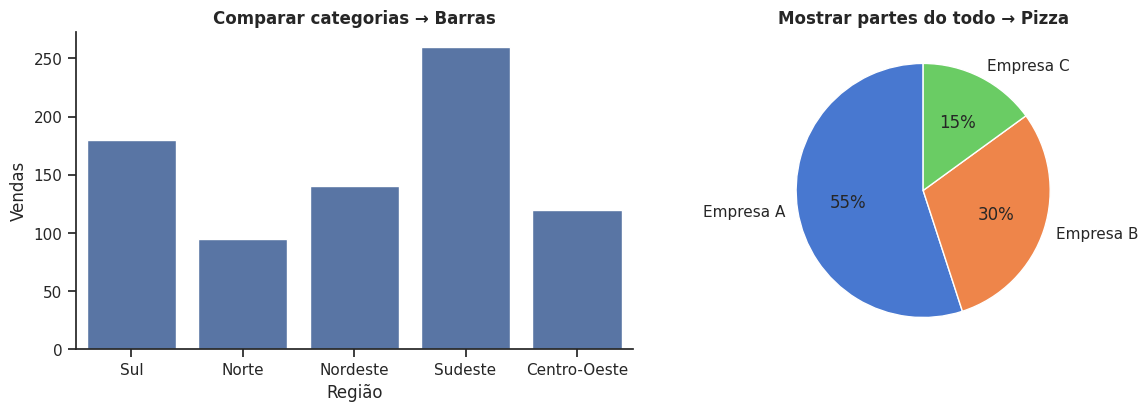

In [ ]:
# 👀 Primeiro contato: os mesmos dados podem pedir gráficos diferentes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(data=vendas_regiao, x='regiao', y='vendas', color='#4C72B0', ax=axes[0])
axes[0].set_title('Comparar categorias → Barras', fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Vendas')
axes[0].spines[['top', 'right']].set_visible(False)

# Adaptado para usar a paleta de cores do Seaborn
axes[1].pie(participacao['percentual'], labels=participacao['empresa'], autopct='%1.0f%%', startangle=90, colors=sns.color_palette(), wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Mostrar partes do todo → Pizza', fontweight='bold')

plt.show()


---
## 1. 📊 Gráfico de Barras
<a id='barras'></a>

O gráfico de barras é uma das formas mais diretas de comparar valores entre categorias. Cada barra representa uma categoria, e o tamanho da barra representa o valor associado a ela.

Ele funciona bem quando queremos responder perguntas como: qual região vendeu mais? Qual produto teve melhor desempenho? Qual categoria aparece com mais frequência?

### Quando ele funciona bem
- Comparação entre categorias distintas.
- Rankings, como maiores vendas, maiores custos ou produtos mais procurados.
- Poucas categorias, de preferência em uma quantidade que ainda seja fácil de ler.

### Quando ele começa a falhar
- Quando existem categorias demais e os rótulos ficam apertados.
- Quando a intenção é mostrar partes de um todo, especialmente com poucas categorias.
- Quando o dado é contínuo, como idade, salário, altura ou tempo. Nesse caso, normalmente queremos um histograma.

> 💡 Em gráficos de barras, o eixo deve começar no zero. Quando o eixo é cortado, pequenas diferenças podem parecer muito maiores do que realmente são.


In [ ]:
# 📊 Exemplo real: vendas por região
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=vendas_regiao.sort_values('vendas', ascending=False),
            x='regiao', y='vendas', color='#4C72B0', ax=ax)

ax.set_title('Vendas por região', fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Vendas')
ax.set_ylim(120, 300)  # eixo começando em zero mostrar com eixo começando em 80
ax.spines[['top', 'right']].set_visible(False)

plt.show()

print('Pergunta respondida: qual região vendeu mais?')


NameError: name 'plt' is not defined

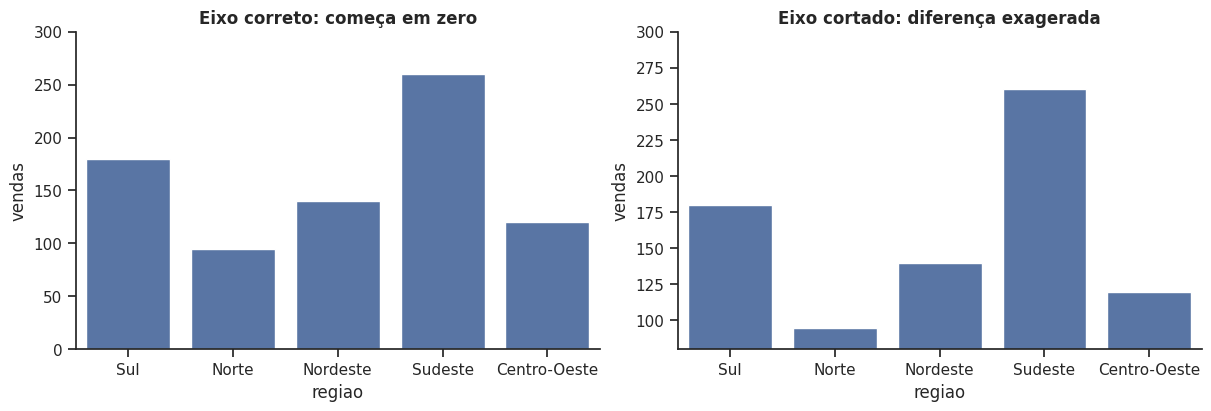

In [ ]:
# ⚠️ Cuidado: cortar o eixo Y pode distorcer a percepção
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(data=vendas_regiao, x='regiao', y='vendas', color='#4C72B0', ax=axes[0])
axes[0].set_title('Eixo correto: começa em zero', fontweight='bold')
axes[0].set_ylim(0, 300)
axes[0].spines[['top', 'right']].set_visible(False)

sns.barplot(data=vendas_regiao, x='regiao', y='vendas', color='#4C72B0', ax=axes[1])
axes[1].set_title('Eixo cortado: diferença exagerada', fontweight='bold')
axes[1].set_ylim(80, 300)
axes[1].spines[['top', 'right']].set_visible(False)

plt.show()


### 🏋️ Atividade — Barras

Use a tabela `vendas_regiao` para criar um gráfico de barras em ordem crescente.

Depois de gerar o gráfico, observe: qual região vendeu menos? A ordenação ajudou a leitura?


In [ ]:
# 👇 Escreva sua solução aqui
# Dica: use vendas_regiao.sort_values('vendas')
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=vendas_regiao.sort_values('vendas'),
    x='regiao',
    y='vendas',
    color='#4C72B0',
    ax=ax
)

ax.set_title('Vendas por região (ordem crescente)', fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Vendas')
ax.set_ylim(0, 300)
ax.spines[['top', 'right']].set_visible(False)

plt.show()


---
## 2. 🥧 Gráfico de Pizza
<a id='pizza'></a>

O gráfico de pizza mostra como um total se divide em partes. Cada fatia representa uma porcentagem do todo, e a soma das fatias deve representar 100%.

Ele é mais útil quando existem poucas categorias e a mensagem principal é proporcional: uma parte domina? As partes estão equilibradas? Alguma categoria representa uma parcela muito pequena?

### Quando ele funciona bem
- Participação de mercado.
- Distribuição percentual entre poucas categorias.
- Situações em que a leitura aproximada já é suficiente.

### Quando ele começa a falhar
- Muitas categorias, porque as fatias ficam difíceis de comparar.
- Valores muito parecidos entre si, porque o olho humano não compara ângulos com precisão.
- Comparações entre grupos diferentes. Nesses casos, barras costumam ser mais claras.

> 💡 Se a pizza precisa de muita legenda ou explicação para ser entendida, provavelmente ela não está fazendo bem o trabalho.


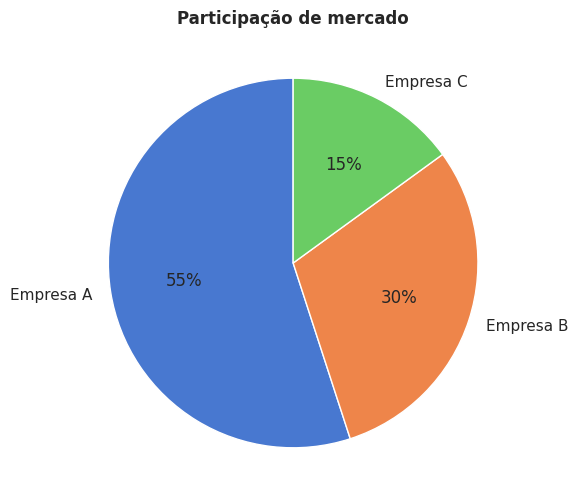

Pergunta respondida: qual empresa tem a maior fatia do mercado?


In [ ]:
# 🥧 Exemplo real: participação de mercado
fig, ax = plt.subplots(figsize=(6, 6))

# Adaptado para usar a paleta de cores do Seaborn
ax.pie(
    participacao['percentual'],
    labels=participacao['empresa'],
    autopct='%1.0f%%',
    startangle=90,
    colors=sns.color_palette(),
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Participação de mercado', fontweight='bold')
plt.show()

print('Pergunta respondida: qual empresa tem a maior fatia do mercado?')


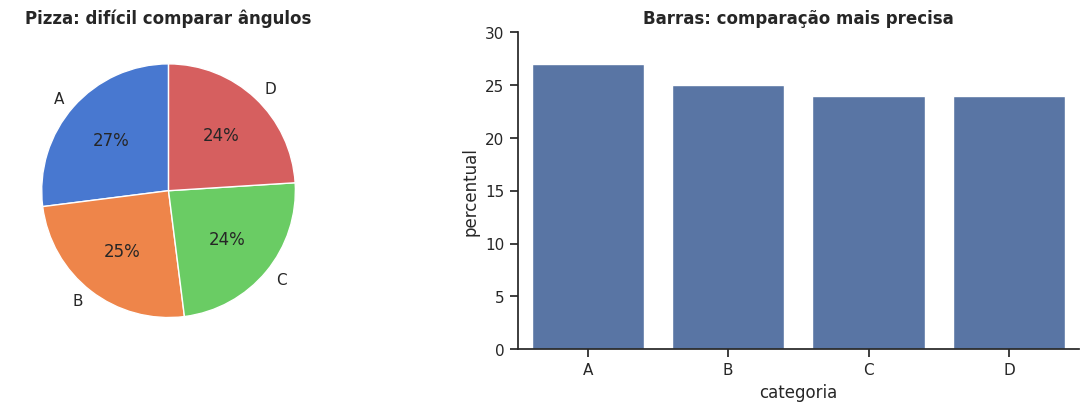

In [ ]:
# Pizza vs barras: quando as diferenças são próximas, barras ficam mais claras
fatias_parecidas = pd.DataFrame({
    'categoria': ['A', 'B', 'C', 'D'],
    'percentual': [27, 25, 24, 24]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Adaptado para usar a paleta de cores do Seaborn
axes[0].pie(fatias_parecidas['percentual'], labels=fatias_parecidas['categoria'], autopct='%1.0f%%', startangle=90, colors=sns.color_palette())
axes[0].set_title('Pizza: difícil comparar ângulos', fontweight='bold')

sns.barplot(data=fatias_parecidas, x='categoria', y='percentual', color='#4C72B0', ax=axes[1])
axes[1].set_title('Barras: comparação mais precisa', fontweight='bold')
axes[1].set_ylim(0, 30)
axes[1].spines[['top', 'right']].set_visible(False)

plt.show()


### 🏋️ Atividade — Pizza

Observe a tabela `participacao` e pense na mensagem principal antes de olhar para o código.

Depois, compare a pizza com uma versão em barras usando os mesmos dados. Qual das duas deixa a comparação mais clara?


In [ ]:
# 👇 Escreva sua solução aqui
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Lado esquerdo: Pizza usando cores do Seaborn
axes[0].pie(
    participacao['percentual'],
    labels=participacao['empresa'],
    autopct='%1.0f%%',
    startangle=90,
    colors=sns.color_palette(),
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Pizza (Participação de Mercado)', fontweight='bold')

# Lado direito: Barras usando Seaborn
sns.barplot(
    data=participacao,
    x='empresa',
    y='percentual',
    color='#4C72B0',
    ax=axes[1]
)
axes[1].set_title('Barras (Comparação Direta)', fontweight='bold')
axes[1].set_xlabel('Empresa')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_ylim(0, 70)
axes[1].spines[['top', 'right']].set_visible(False)

plt.show()


---
## 3. 📈 Histograma
<a id='histograma'></a>

O histograma é usado para entender a distribuição de uma variável numérica. Ele divide os valores em intervalos, chamados de **bins**, e mostra quantas observações aparecem em cada intervalo.

Apesar de parecer um gráfico de barras, a lógica é diferente. No gráfico de barras, cada barra é uma categoria. No histograma, cada barra representa uma faixa de valores numéricos contínuos.

### Quando ele funciona bem
- Distribuição de idades, preços, salários, notas, alturas ou tempos.
- Identificação de concentração, dispersão, assimetria e múltiplos picos.
- Primeira leitura exploratória de uma variável numérica.

### Quando ele começa a falhar
- Quando o dado é categórico.
- Quando existem poucos dados.
- Quando a escolha dos bins muda completamente a interpretação.

> 💡 O número de bins influencia muito a leitura. Poucos bins escondem detalhe; bins demais criam ruído. Vale testar mais de uma configuração.


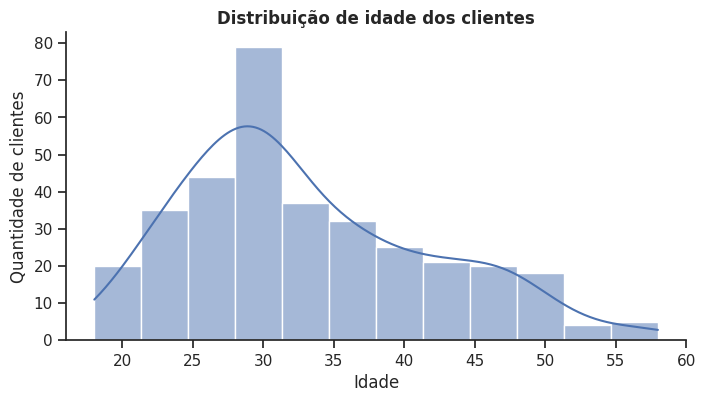

Pergunta respondida: onde as idades estão mais concentradas?


In [ ]:
# 📈 Exemplo real: distribuição de idade dos clientes
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(data=idades, x='idade', bins=12, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Distribuição de idade dos clientes', fontweight='bold')
ax.set_xlabel('Idade')
ax.set_ylabel('Quantidade de clientes')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

print('Pergunta respondida: onde as idades estão mais concentradas?')


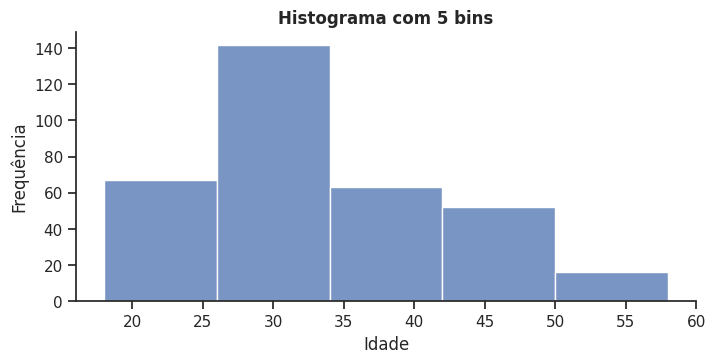

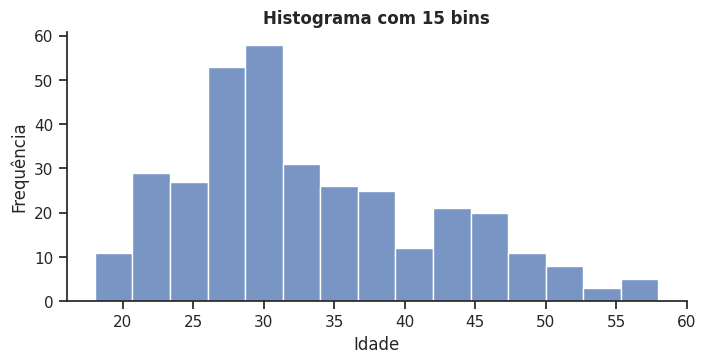

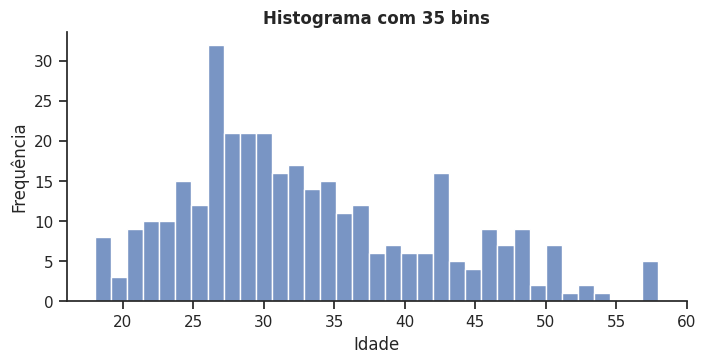

In [ ]:
# O impacto do número de bins
for bins in [5, 15, 35]:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.histplot(data=idades, x='idade', bins=bins, color='#4C72B0', ax=ax)
    ax.set_title(f'Histograma com {bins} bins', fontweight='bold')
    ax.set_xlabel('Idade')
    ax.set_ylabel('Frequência')
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()


### 🏋️ Atividade — Histograma

Use o dataset `salarios` para criar um histograma da coluna `salario`.

Depois de visualizar, descreva a distribuição em uma frase: os salários estão concentrados em qual faixa? Existe algum comportamento fora do esperado?


In [ ]:
# 👇 Escreva sua solução aqui
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=salarios,
    x='salario',
    bins=15,
    kde=True,
    color='#4C72B0',
    ax=ax
)

ax.set_title('Distribuição de Salários dos Funcionários', fontweight='bold')
ax.set_xlabel('Salário (R$)')
ax.set_ylabel('Quantidade de Funcionários')
ax.spines[['top', 'right']].set_visible(False)

plt.show()


---
## 4. 📦 Boxplot
<a id='boxplot'></a>

O boxplot resume uma distribuição em poucos elementos visuais: mínimo, primeiro quartil, mediana, terceiro quartil, máximo e possíveis outliers.

Ele é especialmente útil quando queremos comparar vários grupos lado a lado sem precisar olhar todos os valores individualmente. Em vez de mostrar cada ponto, ele mostra um resumo da posição e da dispersão dos dados.

### Quando ele funciona bem
- Comparação de distribuições entre grupos.
- Identificação rápida de outliers.
- Leitura da mediana e da variação de cada grupo.

### Quando ele começa a falhar
- Quando o público ainda não sabe interpretar boxplot.
- Quando existem poucos dados.
- Quando a forma da distribuição importa muito, porque o boxplot resume e esconde detalhes internos.

> 💡 Dois grupos podem ter boxplots parecidos e, mesmo assim, distribuições internas diferentes. Por isso o boxplot é ótimo para resumo, mas nem sempre suficiente para investigação.


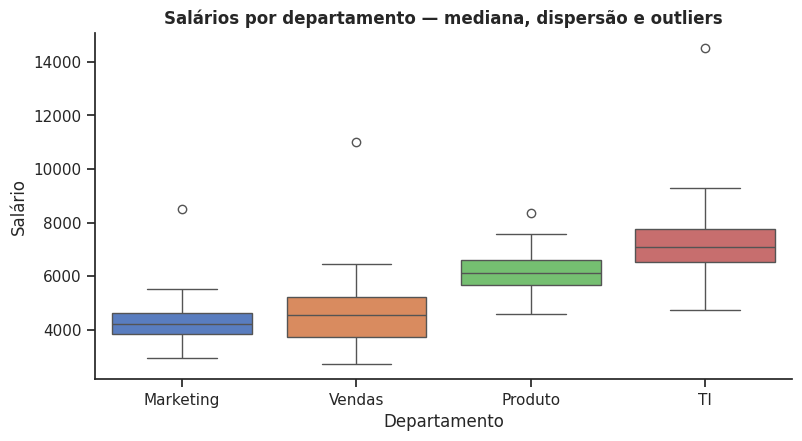

Perguntas respondidas: qual departamento tem maior mediana? Existem outliers?


In [ ]:
# 📦 Exemplo real: salários por departamento
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.boxplot(data=salarios, x='departamento', y='salario', hue='departamento', legend=False, ax=ax)
ax.set_title('Salários por departamento — mediana, dispersão e outliers', fontweight='bold')
ax.set_xlabel('Departamento')
ax.set_ylabel('Salário')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

print('Perguntas respondidas: qual departamento tem maior mediana? Existem outliers?')


In [ ]:
# Anatomia do boxplot: calculando os principais pontos de um grupo
grupo = salarios.query("departamento == 'TI'")['salario']
q1 = grupo.quantile(0.25)
mediana = grupo.quantile(0.50)
q3 = grupo.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print('Resumo do departamento TI')
print(f'Q1: R$ {q1:,.0f}')
print(f'Mediana: R$ {mediana:,.0f}')
print(f'Q3: R$ {q3:,.0f}')
print(f'IQR: R$ {iqr:,.0f}')
print(f'Limite inferior: R$ {limite_inferior:,.0f}')
print(f'Limite superior: R$ {limite_superior:,.0f}')


Resumo do departamento TI
Q1: R$ 6,512
Mediana: R$ 7,089
Q3: R$ 7,750
IQR: R$ 1,238
Limite inferior: R$ 4,655
Limite superior: R$ 9,607


### 🏋️ Atividade — Boxplot

Crie um boxplot das notas por turma usando o dataset `notas`.

Observe a mediana, a variação e os pontos fora do padrão. Qual turma parece mais consistente? Alguma turma apresenta valores extremos?


In [ ]:
# 👇 Escreva sua solução aqui
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.boxplot(
    data=notas,
    x='turma',
    y='nota',
    hue='turma',
    legend=False,
    ax=ax
)

ax.set_title('Distribuição de Notas por Turma (Boxplot)', fontweight='bold')
ax.set_xlabel('Turma')
ax.set_ylabel('Nota')
ax.spines[['top', 'right']].set_visible(False)

plt.show()


---
## 5. 🎻 Gráfico de Violino
<a id='violino'></a>

O gráfico de violino mostra a distribuição de uma variável numérica por grupo, mas com mais detalhe visual do que o boxplot. A largura do violino indica onde há maior concentração de dados.

Ele ajuda quando queremos enxergar a forma da distribuição: se os dados estão concentrados em uma faixa, se existem dois grupos internos, se a distribuição é espalhada ou se há assimetria.

### Quando ele funciona bem
- Comparação da forma da distribuição entre grupos.
- Situações em que a mediana não conta a história completa.
- Análises em que podem existir múltiplos picos ou subgrupos internos.

### Quando ele começa a falhar
- Quando existem poucos dados, porque a curva pode sugerir um padrão que não é confiável.
- Quando o público não conhece esse tipo de gráfico.
- Quando a análise só precisa de uma comparação rápida de medianas.

> 💡 Boxplot e violino não são concorrentes. O boxplot resume; o violino revela a forma. Em análises mais completas, os dois podem aparecer juntos.


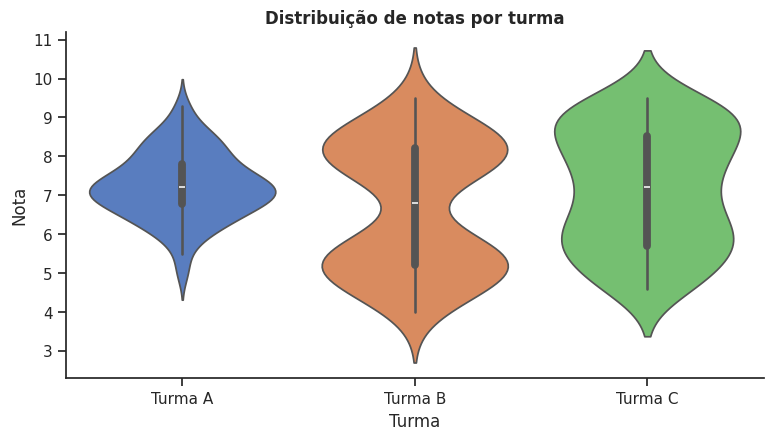

Pergunta respondida: qual é a forma completa da distribuição de cada turma?


In [ ]:
# 🎻 Exemplo real: notas de três turmas
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.violinplot(data=notas, x='turma', y='nota', hue='turma', legend=False, inner='box', ax=ax)
ax.set_title('Distribuição de notas por turma', fontweight='bold')
ax.set_xlabel('Turma')
ax.set_ylabel('Nota')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

print('Pergunta respondida: qual é a forma completa da distribuição de cada turma?')


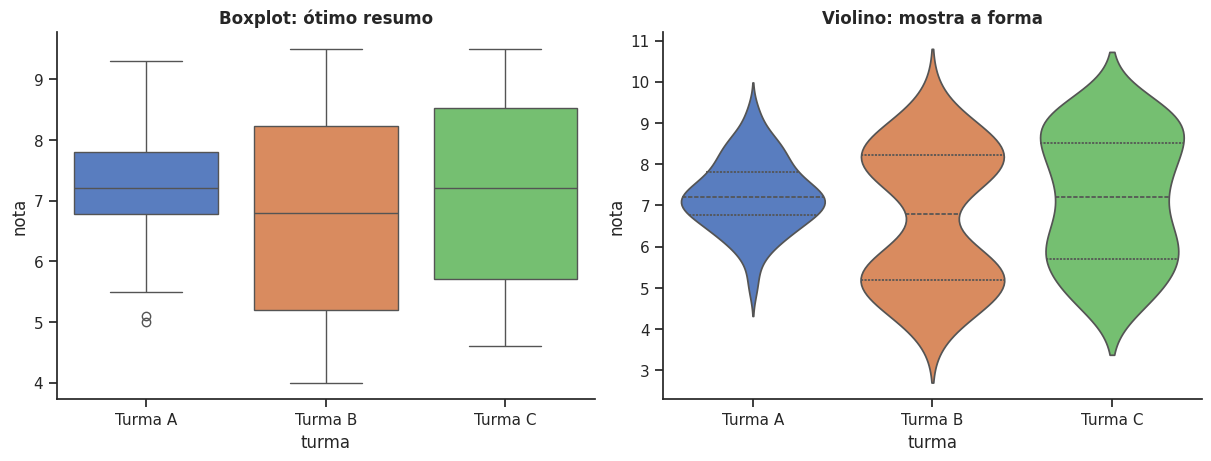

In [ ]:
# Boxplot vs Violino: resumo vs forma completa
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

sns.boxplot(data=notas, x='turma', y='nota', hue='turma', legend=False, ax=axes[0])
axes[0].set_title('Boxplot: ótimo resumo', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

sns.violinplot(data=notas, x='turma', y='nota', hue='turma', legend=False, inner='quartile', ax=axes[1])
axes[1].set_title('Violino: mostra a forma', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.show()


### 🏋️ Atividade — Violino

Compare as turmas A, B e C usando um gráfico de violino.

Procure sinais de concentração, dispersão e possíveis grupos internos. Alguma turma parece ter dois comportamentos diferentes dentro dela?


In [ ]:
# 👇 Escreva sua solução aqui
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.violinplot(
    data=notas,
    x='turma',
    y='nota',
    hue='turma',
    legend=False,
    inner='box',
    ax=ax
)

ax.set_title('Distribuição de Notas por Turma (Gráfico de Violino)', fontweight='bold')
ax.set_xlabel('Turma')
ax.set_ylabel('Nota')
ax.spines[['top', 'right']].set_visible(False)

plt.show()


---
## Atividade de Fixação — Qual gráfico eu usaria para...?
<a id='fixacao'></a>

A proposta aqui é praticar a escolha do gráfico antes de pensar no código. Para cada situação, escolha um dos cinco gráficos e justifique em uma frase.

1. Vendas mensais de 4 lojas ao longo do ano.
2. Participação de mercado de 3 empresas concorrentes.
3. Distribuição de salários de 500 funcionários.
4. Identificar se há funcionários com salário muito acima da média.
5. Comparar a distribuição de notas entre turmas A, B e C.

Mais importante do que acertar o nome do gráfico é conseguir explicar o motivo da escolha. Uma boa justificativa conecta o gráfico com a pergunta da análise.


In [ ]:
# ✍️ Preencha suas respostas aqui
respostas = {
    1: {'grafico': 'Gráfico de barras', 'justificativa': 'Permite comparar facilmente valores entre categorias ao longo do tempo.'},
    2: {'grafico': 'Gráfico de pizza', 'justificativa': 'Mostra a composição de partes de um todo para poucas categorias (3 empresas).'},
    3: {'grafico': 'Histograma', 'justificativa': 'Ideal para entender a distribuição e frequência de dados contínuos, como salários.'},
    4: {'grafico': 'Boxplot', 'justificativa': 'Excelente para identificar resumidamente a dispersão e visualizar valores extremos (outliers).'},
    5: {'grafico': 'Gráfico de violino', 'justificativa': 'Mostra tanto o resumo estatístico quanto a densidade/forma detalhada da distribuição por grupo.'},
}

pd.DataFrame(respostas).T


,grafico,justificativa
1,,
2,,
3,,
4,,
5,,


In [ ]:
# ✅ Gabarito — rode apenas depois de tentar

gabarito = pd.DataFrame({
    'cenario': [
        'Vendas mensais de 4 lojas ao longo do ano',
        'Participação de mercado de 3 empresas concorrentes',
        'Distribuição de salários de 500 funcionários',
        'Identificar salários muito acima da média',
        'Comparar distribuição de notas entre turmas A, B e C'
    ],
    'grafico': [
        'Gráfico de barras',
        'Gráfico de pizza',
        'Histograma',
        'Boxplot',
        'Gráfico de violino'
    ],
    'motivo': [
        'Compara categorias por período.',
        'Mostra partes de um todo com poucas categorias.',
        'Mostra frequência de valores contínuos.',
        'Destaca outliers rapidamente.',
        'Mostra a forma completa da distribuição por grupo.'
    ]
})

display(gabarito)


,cenario,grafico,motivo
0,Vendas mensais de 4 lojas ao longo do ano,Gráfico de barras,Compara categorias por período.
1,Participação de mercado de 3 empresas concorre...,Gráfico de pizza,Mostra partes de um todo com poucas categorias.
2,Distribuição de salários de 500 funcionários,Histograma,Mostra frequência de valores contínuos.
3,Identificar salários muito acima da média,Boxplot,Destaca outliers rapidamente.
4,"Comparar distribuição de notas entre turmas A,...",Gráfico de violino,Mostra a forma completa da distribuição por gr...


---
## Guia rápido — Qual gráfico para qual pergunta?
<a id='guia'></a>

| Gráfico | Pergunta que responde | Dado necessário | Melhor uso |
|---|---|---|---|
| **Barras** | Quanto cada categoria tem? | Categorias + valores numéricos | Comparar categorias |
| **Pizza** | Qual é a fatia de cada parte? | Categorias + porcentagens do total | Mostrar proporção em poucos grupos |
| **Histograma** | Como os valores estão distribuídos? | Uma variável contínua com muitos valores | Entender frequência e concentração |
| **Boxplot** | Onde está a mediana e há outliers? | Uma variável numérica por grupo | Comparar resumo de distribuições |
| **Violino** | Qual é a forma da distribuição? | Uma variável numérica por grupo, com bastante dados | Comparar formas completas de distribuições |

### Fechamento
A escolha do gráfico começa pela pergunta. Antes de abrir o código, vale sempre fazer três perguntas simples:

1. Estou comparando categorias?
2. Estou mostrando partes de um todo?
3. Estou tentando entender a distribuição de uma variável numérica?

Com essas três perguntas, a escolha do gráfico fica muito mais natural.


In [ ]:
# 📚 Referência rápida de snippets

snippets = {
    'barras': "sns.barplot(data=df, x='categoria', y='valor')",
    'pizza': "plt.pie(df['valor'], labels=df['categoria'], autopct='%1.0f%%', colors=sns.color_palette()) # Integrado com Seaborn",
    'histograma': "sns.histplot(data=df, x='variavel_numerica', bins=15, kde=True)",
    'boxplot': "sns.boxplot(data=df, x='grupo', y='valor')",
    'violino': "sns.violinplot(data=df, x='grupo', y='valor', inner='box')"
}

for nome, snippet in snippets.items():
    print(f'{nome.upper()}:')
    print(snippet)
    print()


BARRAS:
sns.barplot(data=df, x='categoria', y='valor')

PIZZA:
plt.pie(df['valor'], labels=df['categoria'], autopct='%1.0f%%')

HISTOGRAMA:
sns.histplot(data=df, x='variavel_numerica', bins=15, kde=True)

BOXPLOT:
sns.boxplot(data=df, x='grupo', y='valor')

VIOLINO:
sns.violinplot(data=df, x='grupo', y='valor', inner='box')

